# PWAS实现

- 参考文献：Plasma proteomic signatures of social isolation and loneliness associated with morbidity and mortality


In [1]:
from dotenv import load_dotenv
load_dotenv("/mnt/disk1/project/project/aikb/.env")


True

In [2]:
import polars as pl
from datalake import scan_table, get_catalog

catalog = get_catalog()

In [3]:

rename_map = {
    "participant.p131286": "htn_date",
    "participant.p31": "sex",
    "participant.p21003_i0": "age",
    "participant.p21001_i0": "bmi",
    "participant.p1239_i0": "smoking_current",
    "participant.p1249_i0": "smoking_past",
    "participant.p20117_i0": "smoking_pack_years",
    "participant.p6138_i0": "education",
    "participant.p738_i0": "income",
    "participant.p22189": "townsend_di",
    "participant.p54_i0": "assessment_centre",
    "participant.p4080_i0_a0": "systolic_bp_1",
    "participant.p4079_i0_a0": "diastolic_bp_1",
    "participant.p4080_i0_a1": "systolic_bp_2",
    "participant.p4079_i0_a1": "diastolic_bp_2",
    "participant.p2966_i0": "age_htn_diagnosed",
}


hp_df = (
    scan_table("ukb.hypertension_cohort")
    .rename(rename_map)  # Rename field: ukb code to readable name
    .with_columns(  # Processing education field
        pl.col("education")
        .str.strip_chars("[]")
        .str.split(",")
        .list.eval(pl.element().cast(pl.Int32))
        .list.min()
        .replace(-7, 0)  # -7 (无学历) 映射为 0
    ).with_columns(
        pl.col('htn_date').is_not_null().alias('hpt')
    )
)

olink_df = scan_table("ukb.hypertension_cohort").with_columns(
    pl.col("eid").cast(pl.String)
)  # convert eid datatype



In [4]:
# catalog.drop_table("ukb.hpt_cov_clean")
join_tb = catalog.create_table_if_not_exists(
    "ukb.hpt_cov_clean", schema=hp_df.schema.to_arrow()
)
hp_df.collect().write_iceberg(join_tb, "overwrite")

/tmp/ipykernel_1495731/1289319491.py:3: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  "ukb.hpt_cov_clean", schema=hp_df.schema.to_arrow()
Unable to resolve region for bucket warehouse


## 蛋白质组Logistic回归

- 为了获取p值，Logistic回归使用statsmodels包实现
- jupyter notebook的垃圾回收机制有所不同，因此处理大规模数据分析任务容易发生OOM，批量处理方法已重构到独立脚本
- 数据处理脚本： logistics.py



## 拟合模型
**多元逻辑回归模型（Multiple Logistic Regression Model）**

$$
\log\left(\frac{P(\text{hypertension}=1)}{1 - P(\text{hypertension}=1)}\right) = \beta_0 + \beta_1 \cdot \text{protein(x)} + \beta_2 \cdot \text{sex} + \beta_3 \cdot \text{age} + \beta_4 \cdot \text{bmi} + \dots
$$

- **左侧**：logit 变换（自然对数尺度下的对数几率）
- **右侧**：线性组合（蛋白 + 协变量）
- **估计方法**：最大似然估计（MLE）



In [5]:
COVARIANCE_FIELDS = [
    "sex",
    "age",
    "bmi",
    "smoking_current",
    "smoking_past",
    "smoking_pack_years",
    "education",
    "income",
]

OUTCOME_FIELD = "hpt"

OLINK_TABLE = "ukb.olink_instance_0"
COV_TABLE = "ukb.hpt_cov_clean"
RESULT_TABLE = "ukb.pwas_hypertension_logit"


In [6]:
logistic_df = scan_table("ukb.pwas_hypertension_logit").filter(
    ~pl.col("protein").is_in(["olink_instance_0.eid", *list(hp_df.schema.keys())])
)

protein_logistic_result_df = logistic_df.sql(
    "SELECT * FROM self WHERE variable = protein"
)

# sink data to iceberg
protein_logistic_result_tb = catalog.create_table_if_not_exists(
    "ukb.proteome.protein_logistic_result",
    schema=protein_logistic_result_df.schema.to_arrow()
)

# 分批写入iceberg
# for batch_df in protein_logistic_result_df.collect_batches(chunk_size=1_000):
#     protein_logistic_result_tb.append(batch_df.to_arrow())

/tmp/ipykernel_1495731/2669505062.py:2: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  ~pl.col("protein").is_in(["olink_instance_0.eid", *list(hp_df.schema.keys())])
/tmp/ipykernel_1495731/2669505062.py:12: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  schema=protein_logistic_result_df.schema.to_arrow()


In [11]:
import numpy as np

proteo_df = scan_table("ukb.proteome.protein_logistic_result")
or_proteom_logistic_df = proteo_df.with_columns(pl.col('coef').exp().alias('or'))

or_proteom_logistic_df.head().collect()

protein,variable,coef,std_err,z,pvalue,ci_lower,ci_upper,or
str,str,f64,f64,f64,f64,f64,f64,f64
"""endou""","""endou""",0.013081,0.021153,0.618406,0.536308,-0.028379,0.054541,1.013167
"""enah""","""enah""",0.091527,0.019554,4.680783,0.000003,0.053202,0.129851,1.095846
"""elob""","""elob""",0.040678,0.027723,1.467283,0.142299,-0.013659,0.095014,1.041517
"""eloa""","""eloa""",0.103457,0.016811,6.154148,7.5482e-10,0.070508,0.136406,1.108998
"""eln""","""eln""",0.243774,0.030236,8.062266,7.4893e-16,0.184511,0.303036,1.276055


In [12]:
tb = catalog.create_table_if_not_exists(
    identifier="ukb.proteome.protein_logistic_result_with_or", 
    schema=or_proteom_logistic_df.schema.to_arrow()
    )

# save data
or_proteom_logistic_df.collect().write_iceberg(tb, "overwrite")

/tmp/ipykernel_1490628/141601517.py:3: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  schema=or_proteom_logistic_df.schema.to_arrow()


## PWAS结果分析
- 显著性指标: $p < 0.05$
- 进行Bonferroni校正阈值: $\alpha_{new} = \frac{\alpha}{n}$

In [ ]:
pwas_df = scan_table("ukb.proteome.protein_logistic_result_with_or")

p_standard = 0.05
prot_num = pwas_df.sql("SELECT COUNT(protein) FROM self").collect().item()
bonferroni = p_standard / prot_num
significant_pwas_df = pwas_df.filter(pl.col("pvalue").lt(bonferroni))

top10_risk_protein = significant_pwas_df.sql("SELECT protein FROM self ORDER BY or DESC LIMIT 10").collect().to_series().to_list()
top10_protect_protein = (
    significant_pwas_df.sql("SELECT protein FROM self ORDER BY or ASC LIMIT 10")
    .collect()
    .to_series()
    .to_list()
)

print("Total Protein Count: ", prot_num)
print("Bonferroni threshold: ", bonferroni)
print(
    "Significant protein count(Bonferroni Correction): ",
    significant_pwas_df.sql("SELECT COUNT(protein) FROM self").collect().item(),
)
print("top10_risk_protein", top10_risk_protein)
print("top10_protect_protein", top10_protect_protein)


Total Protein Count:  2923
Bonferroni threshold:  1.7105713308244956e-05
Significant protein count(Bonferroni Correction):  1026
top10_risk_protein ['f9', 'serpina1', 'ambp', 'ace', 'col18a1', 'asgr1', 'bmper', 'rnase1', 'heg1', 'hyal1']
top10_protect_protein ['itgav', 'gsn', 'pon3', 'adgrg2', 'pla2g7', 'mxra8', 'apof', 'fgfbp1', 'met', 'itga11']


## 可视化

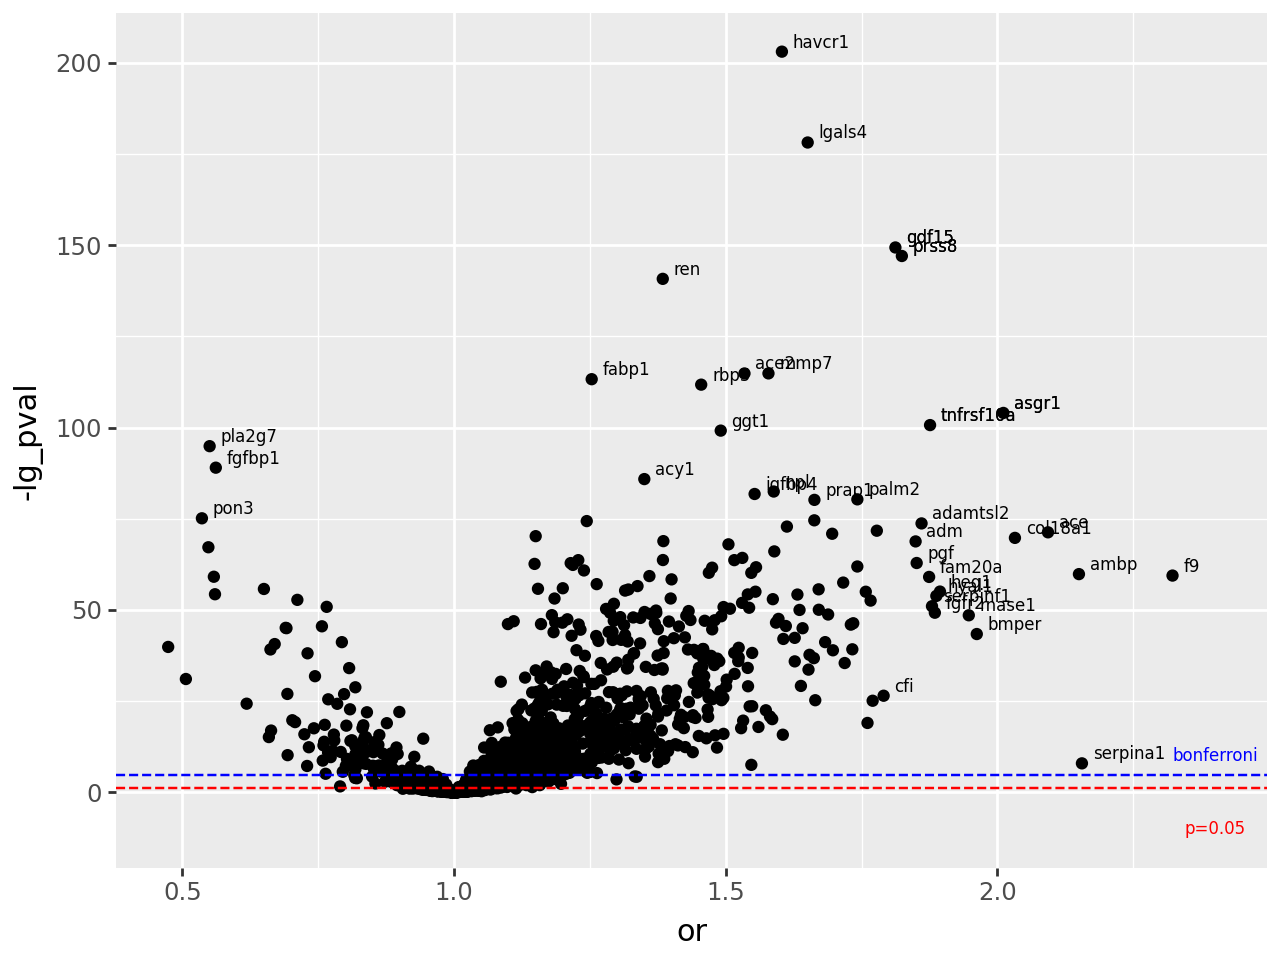

In [51]:
import numpy as np
from plotnine import annotate, geom_hline, geom_text, ggplot, aes, geom_point, scale_color_gradient2

data = (
    pwas_df.select(["protein", "or", "pvalue"])
    .with_columns(
        pl.col("pvalue").map_batches(lambda x: -np.log10(x)).alias("-lg_pval")
    )
    .collect()
    .to_pandas()
)

data["score"] = data["or"] * np.log10(data["-lg_pval"])
top_n_pval = data.nlargest(20, "-lg_pval")
data["sort_or"] = np.square(data["or"] - 1)
top_n_or = data.nlargest(20, "sort_or")

(
    ggplot(data=data, mapping=aes(x="or", y="-lg_pval"))
    + geom_point()
    # + scale_color_gradient2(low="green", mid="#e0e0e0", high="red", midpoint=1)
    + geom_text(
        data=top_n_pval,
        mapping=aes(label="protein"),
        size=6,
        ha="left",
        va="bottom",
        nudge_x=0.02,
    )
    + geom_text(
        data=top_n_or,
        mapping=aes(label="protein"),
        size=6,
        ha="left",
        va="bottom",
        nudge_x=0.02,
    )
    + geom_hline(yintercept=-np.log10(0.05), linetype="dashed", size=0.5, color="red")
    + annotate("text", 2.4, -10, label="p=0.05", color="red", size=6)
    + geom_hline(
        yintercept=-np.log10(bonferroni), linetype="dashed", size=0.5, color="blue"
    )
    + annotate("text", 2.4, 10, label=f"bonferroni", color="blue", size=6)
)

## 限制性立方条样非线性检验(RCS)

In [58]:
# RCS检验结果数据
# 使用rcs.py进行批处理
rcs_res = scan_table("ukb.pwas_rcs_nonlinearity")

### RCS 非线性检验结果汇总

- **模型类型**: Logistic 回归
- **节点(Knots)设置**: 4 个节点，分别位于第 5%、35%、65%、95% 分位数
- **协变量**: sex, age, bmi, smoking_current, smoking_past, smoking_pack_years, education, income
- **非线性检验方法**: 似然比检验 (Likelihood Ratio Test)，$H_0$: 线性假设成立

In [59]:
rcs_df = rcs_res.collect()

n_total = rcs_df.height
n_linear = rcs_df.filter(pl.col("is_linear").eq(1)).height
n_nonlinear = n_total - n_linear

print(f"Total proteins tested: {n_total}")
print(f"Linear (p_nonlinearity >= 0.05): {n_linear} ({n_linear/n_total*100:.1f}%)")
print(f"Nonlinear (p_nonlinearity < 0.05): {n_nonlinear} ({n_nonlinear/n_total*100:.1f}%)")

nonlinear_df = rcs_df.filter(pl.col("is_linear").eq(0)).sort("p_nonlinearity")
print(f"\nTop 10 most significant nonlinear proteins:")
nonlinear_df.select(["exposure", "p_nonlinearity", "lr_statistic", "n_valid"]).head(10)

Total proteins tested: 2923
Linear (p_nonlinearity >= 0.05): 1580 (54.1%)
Nonlinear (p_nonlinearity < 0.05): 1343 (45.9%)

Top 10 most significant nonlinear proteins:


exposure,p_nonlinearity,lr_statistic,n_valid
str,f64,f64,i64
"""ren""",0.0,2065.97774,46862
"""pik3ip1""",3.2302e-74,338.437518,46859
"""ace""",1.3772e-69,317.11659,40698
"""rgmb""",1.3927e-63,289.463249,47269
"""layn""",5.5717e-63,286.690339,46420
"""tnfrsf19""",1.9451e-62,284.189952,47253
"""nectin4""",5.3100e-62,282.181364,47002
"""jam2""",2.0906e-57,261.01979,47269
"""ephb4""",5.5389e-57,259.071101,47425


### RCS 批量曲线预测

对非线性显著的蛋白质批量拟合 RCS 模型，生成预测曲线数据（OR 及 95% CI）和分位数参考表。

数据存储于 Iceberg 表:
- `ukb.pwas_rcs_curve`: 预测曲线数据（每个蛋白 100 个网格点的 OR 值和 CI）
- `ukb.pwas_rcs_quantile_table`: 分位数参考表（第 5、35、65、95 分位数的 OR 值和 CI）

批处理脚本: `lib/rcs.py` 中的 `batch_rcs_curve_predict()` 函数

In [3]:
from stats import RCS_CURVE_TABLE, RCS_QUANTILE_TABLE

rcs_curve_df = scan_table(RCS_CURVE_TABLE)
rcs_quant_df = scan_table(RCS_QUANTILE_TABLE)

print("Curve data schema:")
print(rcs_curve_df.collect_schema())
print(f"\nCurve data row count: {rcs_curve_df.select(pl.len()).collect().item()}")
print(f"Unique proteins in curve data: {rcs_curve_df.select(pl.col('exposure').n_unique()).collect().item()}")

print("\nQuantile table preview:")
rcs_quant_df.head(12).collect()

Curve data schema:
Schema({'analysis_id': String, 'exposure': String, 'x': Float64, 'log_or': Float64, 'or': Float64, 'or_ci_lower': Float64, 'or_ci_upper': Float64})

Curve data row count: 0
Unique proteins in curve data: 0

Quantile table preview:


analysis_id,exposure,quantile,x_val,or,ci_lower,ci_upper,p_overall,p_nonlinear,n_valid
str,str,i32,f64,f64,f64,f64,f64,f64,i32


### RCS 非线性检验火山图

X轴: 似然比统计量 (LR statistic)，Y轴: $-\log_{10}(p_{nonlinearity})$

In [ ]:
import numpy as np
from plotnine import (
    ggplot, aes, geom_point, geom_hline, geom_text,
    annotate, labs, theme_minimal, scale_color_manual
)

rcs_plot_df = (
    rcs_df
    .with_columns(
        pl.col("p_nonlinearity").map_batches(lambda x: -np.log10(x)).alias("-lg_p")
    )
    .with_columns(
        pl.when(pl.col("is_linear").eq(0))
        .then(pl.lit("Nonlinear"))
        .otherwise(pl.lit("Linear"))
        .alias("linearity")
    )
)

top_nonlinear = rcs_plot_df.sort("p_nonlinearity").head(15)

(
    ggplot(data=rcs_plot_df.to_pandas(), mapping=aes(x="lr_statistic", y="-lg_p", color="linearity"))
    + geom_point(size=1, alpha=0.6)
    + scale_color_manual(values={"Nonlinear": "#d62728", "Linear": "#1f77b4"})
    + geom_hline(yintercept=-np.log10(0.05), linetype="dashed", color="red", size=0.5)
    + geom_text(
        data=top_nonlinear.to_pandas(),
        mapping=aes(label="exposure"),
        size=5, ha="left", va="bottom", nudge_x=0.5,
        color="black",
    )
    + annotate("text", x=max(rcs_plot_df["lr_statistic"])*0.7, y=-np.log10(0.05)+0.3, label="p=0.05", color="red", size=6)
    + labs(
        title="RCS Nonlinearity Test",
        x="Likelihood Ratio Statistic",
        y="$-\\log_{10}(p_{nonlinearity})$",
        color="Linearity",
    )
    + theme_minimal()
)

### RCS 曲线可视化（关键非线性蛋白）

选取非线性检验最显著的 Top N 蛋白绘制 RCS 曲线图。每张图展示:
- X轴: 蛋白质表达水平
- Y轴: OR 值（以中位数为参照，OR=1）
- 阴影区域: 95% CI
- 标注: $p_{nonlinear}$ 值

In [ ]:
from plotnine import geom_line, geom_ribbon, facet_wrap, theme, element_text

top_n = 6
top_proteins = (
    rcs_df.filter(pl.col("is_linear").eq(0))
    .sort("p_nonlinearity")
    .head(top_n)
    .select("exposure")
    .to_series()
    .to_list()
)

curve_data = (
    rcs_curve_df
    .filter(pl.col("exposure").is_in(top_proteins))
    .collect()
    .to_pandas()
)

p_nonlinear_map = dict(
    rcs_df.filter(pl.col("exposure").is_in(top_proteins))
    .select(["exposure", "p_nonlinearity"])
    .collect()
    .iter_rows()
)

def format_p(p):
    if p < 1e-10:
        return f"p < 1e-10"
    elif p < 0.001:
        return f"p = {p:.2e}"
    else:
        return f"p = {p:.4f}"

curve_data["p_label"] = curve_data["exposure"].map(
    lambda x: format_p(p_nonlinear_map.get(x, 1.0))
)
curve_data["panel"] = curve_data["exposure"] + "\n(" + curve_data["p_label"] + ")"

(
    ggplot(data=curve_data, mapping=aes(x="x", y="or"))
    + geom_ribbon(aes(ymin="or_ci_lower", ymax="or_ci_upper"), alpha=0.2, fill="steelblue")
    + geom_line(color="steelblue", size=1)
    + geom_hline(yintercept=1, linetype="dashed", color="gray", size=0.5)
    + facet_wrap("panel", ncol=3, scales="free_x")
    + labs(
        x="Protein Level",
        y="OR (95% CI)",
        title=f"RCS Curves - Top {top_n} Nonlinear Proteins",
    )
    + theme_minimal()
    + theme(strip_text=element_text(size=8))
)

### 单蛋白 RCS 曲线（交互式选取）

选取单个蛋白绘制高分辨率 RCS 曲线图，适合论文主图使用。

In [ ]:
PROTEIN_NAME = "f9"

protein_curve = (
    rcs_curve_df
    .filter(pl.col("exposure") == PROTEIN_NAME)
    .collect()
    .to_pandas()
)

p_val = (
    rcs_df.filter(pl.col("exposure") == PROTEIN_NAME)
    .select("p_nonlinearity")
    .collect()
    .item()
)

(
    ggplot(data=protein_curve, mapping=aes(x="x", y="or"))
    + geom_ribbon(aes(ymin="or_ci_lower", ymax="or_ci_upper"), alpha=0.2, fill="steelblue")
    + geom_line(color="steelblue", size=1.2)
    + geom_hline(yintercept=1, linetype="dashed", color="gray", size=0.5)
    + labs(
        x=f"{PROTEIN_NAME} Level",
        y="OR (95% CI)",
        title=f"RCS Curve: {PROTEIN_NAME} — P_nonlinear = {format_p(p_val)}",
    )
    + theme_minimal()
)

### 分位数参考表

以第 5 百分位数为参照 (OR=1)，展示各分位数点的 OR 值及 95% CI。
仅展示非线性显著的蛋白质。

In [ ]:
nonlinear_exposures = (
    rcs_df.filter(pl.col("is_linear").eq(0))
    .sort("p_nonlinearity")
    .select("exposure")
    .head(30)
    .to_series()
    .to_list()
)

quant_display = (
    rcs_quant_df
    .filter(pl.col("exposure").is_in(nonlinear_exposures))
    .collect()
    .with_columns([
        pl.col("or").round(3).alias("OR"),
        pl.col("ci_lower").round(3).alias("CI_lower"),
        pl.col("ci_upper").round(3).alias("CI_upper"),
        pl.col("p_nonlinear").map_batches(lambda x: x.apply(lambda v: f"{v:.2e}" if v < 0.001 else f"{v:.4f}")).alias("P_nonlinear"),
    ])
)

print(f"Quantile reference table (top {len(nonlinear_exposures)} nonlinear proteins):")
print(f"Reference: 5th percentile (OR=1)")
quant_display.select(["exposure", "quantile", "x_val", "OR", "CI_lower", "CI_upper", "P_nonlinear"])

### RCS 模型设定汇总表

| 参数 | 值 |
| :--- | :--- |
| 模型类型 | Logistic 回归 |
| 结局变量 | 高血压 (hpt: 0/1) |
| 连续变量 | 蛋白质表达水平 (Olink NPX) |
| 节点数量 | 4 |
| 节点位置 | 第 5%、35%、65%、95% 分位数 |
| 协变量 | sex, age, bmi, smoking_current, smoking_past, smoking_pack_years, education, income |
| 非线性检验 | 似然比检验, $H_0$: 线性假设成立 |
| 显著性水平 | $\\alpha = 0.05$ |

In [ ]:
catalog.create_namespace('method')

In [65]:
scan_table("method.stats.regression.logistic.binary_logistic").collect()

analysis_id,study_name,exposure,variable,coef,std_err,z,pvalue,ci_lower,ci_upper
str,str,str,str,f64,f64,f64,f64,f64,f64
"""8c96ff84-2936-49c6-bdca-9942c8…","""hpt_protein_association""","""a1bg""","""const""",-7.791122,0.13265,-58.734303,0.0,-8.051111,-7.531132
"""8c96ff84-2936-49c6-bdca-9942c8…","""hpt_protein_association""","""a1bg""","""a1bg""",0.565771,0.062225,9.092269,9.6993e-20,0.443811,0.687731
"""8c96ff84-2936-49c6-bdca-9942c8…","""hpt_protein_association""","""a1bg""","""sex""",0.486483,0.02353,20.675411,5.7673e-95,0.440366,0.5326
"""8c96ff84-2936-49c6-bdca-9942c8…","""hpt_protein_association""","""a1bg""","""age""",0.076351,0.001502,50.823445,0.0,0.073407,0.079296
"""8c96ff84-2936-49c6-bdca-9942c8…","""hpt_protein_association""","""a1bg""","""bmi""",0.120518,0.002516,47.910088,0.0,0.115588,0.125448
…,…,…,…,…,…,…,…,…,…
"""8c96ff84-2936-49c6-bdca-9942c8…","""hpt_protein_association""","""zpr1""","""smoking_current""",-0.021228,0.032608,-0.650992,0.515052,-0.085139,0.042683
"""8c96ff84-2936-49c6-bdca-9942c8…","""hpt_protein_association""","""zpr1""","""smoking_past""",-0.051652,0.008718,-5.924959,3.1237e-9,-0.068738,-0.034565
"""8c96ff84-2936-49c6-bdca-9942c8…","""hpt_protein_association""","""zpr1""","""smoking_pack_years""",-0.134397,0.02318,-5.79809,6.7074e-9,-0.179828,-0.088966


In [5]:
catalog.drop_table("method.stats.regression.logistic.binary_logistic")